# 1. Download Data and Preprocess

The event metadata is loaded into a DataFrame and duplicates are removed. The data is further processed by creating new columns, such as start_date, month, and season, which help in organizing the events based on the time of occurrence. The region is assigned based on the geographical coordinates. Finally, the data is split into training and validation sets using stratified sampling to ensure balanced representation across seasons and regions.

## 1.1 Download and Stratified Sample

In [ ]:
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="train.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="events.csv", repo_type="dataset", local_dir="data")
import pandas as pd
import h5py
import IPython
import PIL
import os
from sklearn.model_selection import train_test_split
# this DataFrame contains all of the event meta data
df = pd.read_csv("data/events.csv", parse_dates=["start_utc"])

# this function loads all of the image arrays for a given id
def load_event(id):
    "Load event"
    with h5py.File(f'data/train.h5','r') as f:
        event = {img_type: f[id][img_type][:] for img_type in ['vis', 'ir069', 'ir107', 'vil', 'lght']}
    return event

# import pandas as pd


# delete duplicates
events = df.drop_duplicates(subset=['id']).copy()

#  time devide
events['start_date'] = pd.to_datetime(events['start_utc']).dt.date
events['month'] = pd.to_datetime(events['start_utc']).dt.month
events['season'] = events['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

# devide region
def assign_region(row):
    if row['llcrnrlat'] > 40:  # latitude divide
        return 'North'
    elif row['llcrnrlat'] < 30:
        return 'South'
    elif row['llcrnrlon'] < -100:  # longitude divide
        return 'West'
    else:
        return 'East'

events['region'] = events.apply(assign_region, axis=1)

# split train and validation set using stratified sampling
train_events, val_events = train_test_split(
    events,
    test_size=0.2,  # validation set size
    stratify=events[['season', 'region']],  # stratified sampling based on season and region
    random_state=42
)


train_ids = train_events['id']
val_ids = val_events['id']
print(f"Train Set Size: {len(train_ids)}")
print(f"Validation Set Size: {len(val_ids)}")


## 1.2 Preprocess Data

This section processes the data into the format required for model training. Images from the dataset are normalized using min-max normalization to scale pixel values between 0 and 1. The images are processed for three different channels (vis, ir069, ir107) and concatenated to create the input tensor. This tensor is then permuted to match the required input shape. Additionally, the target variable vil is stored in the pre-allocated tensor. After processing all data, the input and target tensors are reshaped to the final shape for model input. The resulting data is used for training the model.

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

def process_data(event_ids):

    # prepare the data tensor for the model input and target
    N = len(event_ids)
    H, W = 384, 384
    input_channels = 3  
    target_channels = 1 
    frames = 36
    # directly allocate tensor to avoid list append
    data_inputs = torch.empty((N, frames, input_channels, H, W), dtype=torch.float32)
    data_targets = torch.empty((N, frames, target_channels, H, W), dtype=torch.float32)

    for i, id in enumerate(event_ids):
        event = load_event(id)

        # read data and convert to Tensor
        vis = torch.from_numpy(event['vis'].astype(np.float32)).permute(2, 0, 1).unsqueeze(0)
        ir069 = torch.from_numpy(event['ir069'].astype(np.float32)).permute(2, 0, 1).unsqueeze(0)
        ir107 = torch.from_numpy(event['ir107'].astype(np.float32)).permute(2, 0, 1).unsqueeze(0)
        vil = torch.from_numpy(event['vil'].astype(np.float32)).permute(2, 0, 1).unsqueeze(1)  # (36, 384, 384)

        # upsample infrared data to 384x384
        ir069 = F.interpolate(ir069, size=(H, W), mode='bilinear', align_corners=False)
        ir107 = F.interpolate(ir107, size=(H, W), mode='bilinear', align_corners=False)

        # Normalize the input data, min-max normalization
        def normalize(tensor):
            min_val = tensor.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]  # only calculate min once
            max_val = tensor.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0]  # only calculate max once
            return (tensor - min_val) / (max_val - min_val + 1e-8)  # advoid division by zero

        vis = normalize(vis)
        ir069 = normalize(ir069)
        ir107 = normalize(ir107)
        vil = normalize(vil)

        # concat along the channel dimension (3, 36, 384, 384) and permute to (36, 3, 384, 384)
        inputs = torch.cat([vis, ir069, ir107], dim=0).permute(1, 0, 2, 3)  # (36, 3, 384, 384)

        # store the data in the pre-allocated tensor
        data_inputs[i] = inputs
        data_targets[i] = vil

        if (i + 1) % 10 == 0:
            print(f"Processed {i+1}/{N}")
    
    # reshape the data to (N*frames, C, H, W)
    data_inputs = data_inputs.view(N * frames, input_channels, 384, 384)
    data_targets = data_targets.view(N * frames, target_channels, 384, 384)
    return data_inputs, data_targets

train_inputs, train_targets = process_data(train_ids)
val_inputs, val_targets = process_data(val_ids)

# check the final shape
print("Final Input Shape:", train_inputs.shape, "Final Target Shape:", train_targets.shape)
print("Final Input Shape:", val_inputs.shape, "Final Target Shape:", val_targets.shape)

Processed 10/640
Processed 20/640
Processed 30/640
Processed 40/640
Processed 50/640
Processed 60/640
Processed 70/640
Processed 80/640
Processed 90/640
Processed 100/640
Processed 110/640
Processed 120/640
Processed 130/640
Processed 140/640
Processed 150/640
Processed 160/640
Processed 170/640
Processed 180/640
Processed 190/640
Processed 200/640
Processed 210/640
Processed 220/640
Processed 230/640
Processed 240/640
Processed 250/640
Processed 260/640
Processed 270/640
Processed 280/640
Processed 290/640
Processed 300/640
Processed 310/640
Processed 320/640
Processed 330/640
Processed 340/640
Processed 350/640
Processed 360/640
Processed 370/640
Processed 380/640
Processed 390/640
Processed 400/640
Processed 410/640
Processed 420/640
Processed 430/640
Processed 440/640
Processed 450/640
Processed 460/640
Processed 470/640
Processed 480/640
Processed 490/640
Processed 500/640
Processed 510/640
Processed 520/640
Processed 530/640
Processed 540/640
Processed 550/640
Processed 560/640
P

# 2. Create Dataset and Dataloader

A custom Dataset class is defined to handle the processed data. This class inherits from torch.utils.data.Dataset and is responsible for returning the inputs and targets when indexed. The __init__ method initializes the dataset, while the __getitem__ method retrieves individual samples for training. The __len__ method returns the number of samples in the dataset. This class is useful for creating a DataLoader, which handles batching, shuffling, and parallel data loading during model training.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

# Define the Dataset class
class StormDataset(Dataset):
    def __init__(self, data_inputs, data_targets):
        self.data_inputs = data_inputs
        self.data_targets = data_targets
    def __len__(self):
        return self.data_inputs.shape[0]

    def __getitem__(self, idx):
        inputs = self.data_inputs[idx]
        target = self.data_targets[idx]

        return inputs, target

In [ ]:
# Create the DataLoader
batch_size = 36
train_dataset = StormDataset(train_inputs, train_targets)
train_loader = DataLoader(train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)
val_dataset =StormDataset(val_inputs, val_targets)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)
train_input, train_target = next(iter(train_loader))
print(f"✅ Data Loaded: Input {train_input.shape}, Target {train_target.shape}")
val_input, val_target = next(iter(val_loader))
print(f"✅ Data Loaded: Input {val_input.shape}, Target {val_target.shape}")

✅ Data Loaded: Input torch.Size([36, 3, 384, 384]), Target torch.Size([36, 1, 384, 384])
✅ Data Loaded: Input torch.Size([36, 3, 384, 384]), Target torch.Size([36, 1, 384, 384])


# 3. Define Model (UNetGan)

A Generative Adversarial Network (GAN) is defined using a UNetGenerator class for the generator model. The UNetGenerator is a type of neural network commonly used for image-to-image tasks. It consists of an encoder-decoder architecture with skip connections to preserve spatial information. The encoder progressively reduces the spatial dimensions of the input, while the decoder reconstructs the output. The generator aims to generate realistic images, and the discriminator's goal is to distinguish between real and generated images. The generator and discriminator are trained alternately during the training process.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import torch.nn.functional as F

class UNetGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
      super(UNetGenerator, self).__init__()

      # encoder
      self.enc1 = self.conv_block(in_channels, 64)
      self.enc2 = self.conv_block(64, 128)
      self.enc3 = self.conv_block(128, 256)

      # Bottleneck
      self.bottleneck = self.conv_block(256, 512)

      # decoder
      self.up3 = self.up_conv(512, 256)
      self.dec3 = self.conv_block(512, 256)
      self.up2 = self.up_conv(256, 128)
      self.dec2 = self.conv_block(256, 128)
      self.up1 = self.up_conv(128, 64)
      self.dec1 = self.conv_block(128, 64)

      # final output
      self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
      return nn.Sequential(
          nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
          nn.ReLU(inplace=True),
          nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
          nn.ReLU(inplace=True),
      )

    def up_conv(self, in_channels, out_channels):
      return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
      enc1 = self.enc1(x)
      enc2 = self.enc2(F.max_pool2d(enc1, 2))
      enc3 = self.enc3(F.max_pool2d(enc2, 2))

      bottleneck = self.bottleneck(F.max_pool2d(enc3, 2))

      up3 = self.up3(bottleneck)
      dec3 = self.dec3(torch.cat([up3, enc3], dim=1))
      up2 = self.up2(dec3)
      dec2 = self.dec2(torch.cat([up2, enc2], dim=1))
      up1 = self.up1(dec2)
      dec1 = self.dec1(torch.cat([up1, enc1], dim=1))

      return torch.sigmoid(self.final(dec1))


class PatchGANDiscriminator(nn.Module):
    def __init__(self, in_channels=1):
        super(PatchGANDiscriminator, self).__init__()

        def conv_block(in_c, out_c, stride=2):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=4, stride=stride, padding=1),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2, inplace=True)
            )

        self.model = nn.Sequential(
            conv_block(1, 64, stride=2),
            conv_block(64, 128, stride=2),
            conv_block(128, 256, stride=2),
            conv_block(256, 512, stride=1),  # PatchGAN keep the shape as 30x30
            nn.Conv2d(512, 1, kernel_size=4, padding=1)
        )

    def forward(self, x):
        return self.model(x)
    

criterion_gan = nn.BCEWithLogitsLoss()  # more stable than BCELoss
criterion_l1 = nn.L1Loss()  # L1 Loss

def generator_loss(pred_fake, fake_vil, real_vil, lambda_l1=100):
    gan_loss = criterion_gan(pred_fake, torch.ones_like(pred_fake))
    l1_loss = criterion_l1(fake_vil, real_vil)
    return gan_loss + lambda_l1 * l1_loss

def discriminator_loss(pred_real, pred_fake):
    loss_real = criterion_gan(pred_real, torch.ones_like(pred_real))
    loss_fake = criterion_gan(pred_fake, torch.zeros_like(pred_fake))
    return (loss_real + loss_fake) / 2


# 4. Train Model

This section defines the training loop for the GAN. The Adam optimizer is used for both the generator and discriminator, and a learning rate scheduler (CosineAnnealingLR) is applied to gradually decrease the learning rate during training. The training loop iterates through the training data in batches, updating the discriminator (D) and the generator (G) alternately. Mixed precision training (AMP) is used to speed up the process and reduce memory usage. The discriminator is trained on real and fake data, while the generator is updated based on the discriminator's feedback. The loss values for both the generator and discriminator are tracked and displayed in the progress bar. The model with the best generator loss is saved after each epoch.

In [ ]:
generator = UNetGenerator().cuda()
discriminator = PatchGANDiscriminator().cuda()

num_epochs = 50
optimizer_G = optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

# CosineAnnealingLR 
scheduler_G = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_G, T_max=50, eta_min=1e-6)
scheduler_D = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D, T_max=50, eta_min=1e-6)
n_critic = 2  # train D twice more than G

# AMP training
scaler = GradScaler()
best_model = None
best_loss = None
for epoch in range(num_epochs):
    with tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Training)", unit="batch") as pbar:
      for i, (x,y) in enumerate(pbar):
          x, y = x.cuda().to(memory_format=torch.channels_last), y.cuda().to(memory_format=torch.channels_last)

          # =========== Update D ============
          optimizer_D.zero_grad()
          with autocast():  # AMP mixed precision
              pred_real = discriminator(y)
              fake_y = generator(x).detach()
              pred_fake = discriminator(fake_y)
              loss_D = discriminator_loss(pred_real, pred_fake)

          scaler.scale(loss_D).backward()
          scaler.step(optimizer_D)
          scaler.update()

        # =========== Update G ============
          optimizer_G.zero_grad()
          with autocast():
              fake_y = generator(x)
              pred_fake = discriminator(fake_y)

              loss_G = generator_loss(pred_fake, fake_y, y)

          scaler.scale(loss_G).backward()
          scaler.step(optimizer_G)
          scaler.update()
          pbar.set_postfix({'loss_G': loss_G.item(), 'loss_D': loss_D.item()})
      scheduler_G.step()
      scheduler_D.step()



    print(f"Epoch {epoch+1}, Loss_G: {loss_G.item():.4f}, Loss_D: {loss_D.item():.4f}")
    if best_loss is None or loss_G.item() < best_loss:
        best_loss = loss_G.item()
        best_model = generator.state_dict()
        print('Saving best model...')
        torch.save(best_model, f'gan_best_model_epoch{epoch+1}.pth')

# 5. Evaluate and Visualize
In this section, the model's performance is evaluated, and the predictions are visualized. The pre-trained model (with the best weights) is loaded, and the model is set to evaluation mode. A batch from the validation set is fetched, and the model makes predictions on the inputs. The input images (vis, ir069, ir107) and the predicted (prediction) and actual (target) images are visualized for comparison. The function plot_event is defined to plot the images for each frame. Additionally, there is an option to output the visualizations as a GIF for a more dynamic analysis of the frames. The images are displayed with different color maps to emphasize the differences in the data and predictions.

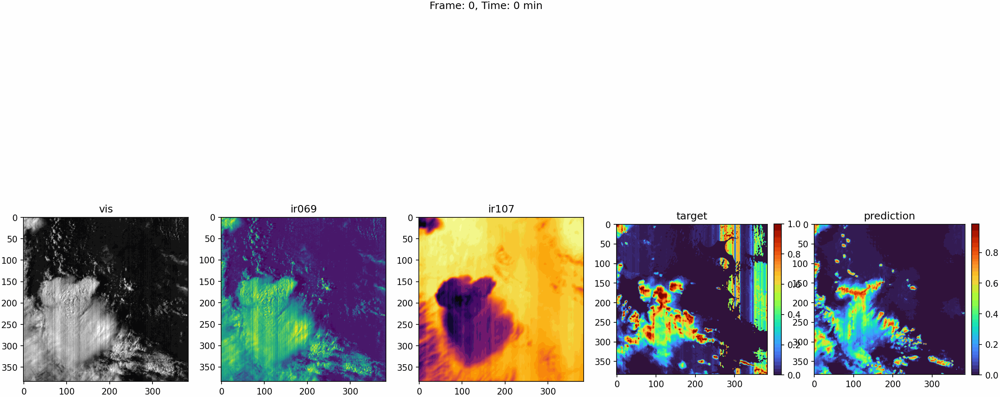

In [ ]:
import matplotlib.pyplot as plt

device="cuda"
model = UNetGenerator().cuda()
model.load_state_dict(best_model)
model.eval()

# fetch a batch from the validation loader
with torch.no_grad():
    count = 0
    for batch in val_loader:

        if count == 2:
            inputs = batch[0].to(device)   # (1, 3, 384, 384)
            target = batch[1].to(device)   # (1, 1, 384, 384)
            break
        count+=1
    prediction = model(inputs)
    target = target.cpu().numpy().squeeze(1)
    prediction = prediction.cpu().numpy().squeeze(1)

vis = inputs[:,0,:,:].cpu().numpy()
ir069 = inputs[:,0,:,:].cpu().numpy()
ir107 = inputs[:,1,:,:].cpu().numpy()

def make_gif(outfile, files, fps=4, loop=0):
    "Helper function for saving GIFs"
    imgs = [PIL.Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='gif', append_images=imgs[1:],
                 save_all=True, duration=int(1000/fps), loop=loop)
    im = IPython.display.Image(filename=outfile)
    im.reload()
    return im

def plot_event(output_gif=False, save_gif=False, frames=36):

    def plot_frame(ti):

        fig,axs = plt.subplots(1,5,figsize=(20,10))
        fig.suptitle(f"Frame: {ti}, Time: {ti*5} min")
        axs[0].imshow(vis[ti], cmap="grey"), axs[0].set_title('vis')
        axs[1].imshow(ir069[ti], cmap="viridis"), axs[1].set_title('ir069')
        axs[2].imshow(ir107[ti], cmap="inferno"), axs[2].set_title('ir107')
        im3 = axs[3].imshow(target[ti], cmap="turbo")
        axs[3].set_title('target')
        fig.colorbar(im3, ax=axs[3], fraction=0.046, pad=0.04)

        im4 = axs[4].imshow(prediction[ti], cmap="turbo")
        axs[4].set_title('prediction')
        fig.colorbar(im4, ax=axs[4], fraction=0.046, pad=0.04)

        axs[4].set_xlim(0,384), axs[1].set_ylim(384,0)

        if output_gif:
            file = f"_temp_{id}_{ti}.png"
            fig.savefig(file, bbox_inches="tight", dpi=150, pad_inches=0.02, facecolor="white")
            plt.close()
        else:
            plt.show()
    if output_gif:
        for ti in range(frames): plot_frame(ti)
        im = make_gif(f"{id}.gif", [f"_temp_{id}_{ti}.png" for ti in range(frames)])
        for ti in range(frames): os.remove(f"_temp_{id}_{ti}.png")
        IPython.display.display(im)
        if not save_gif: os.remove(f"{id}.gif")
    else:
        plot_frame(0)
        plot_frame(17)
        plot_frame(34)

plot_event(output_gif=True, save_gif=True, frames=36)

# 6. Explaining the Model's Prediction


### **🔍 Prediction Analysis & Justification**

#### **1️⃣ Large-Scale Features Captured Well**  
   - The **general cloud structure and intensity** in the `prediction` aligns well with the `target`.
   - The high-intensity zones (red) in both images occur in similar areas.

#### **2️⃣ Blurring & Loss of Fine Details**  
   - The **edges and sharp boundaries** present in the ground truth are **more diffused** in the prediction.
   - The model seems to **smooth out** fine details, which is a common problem with L1/L2 losses.

#### **3️⃣ Regions of High Error**  
- The **edges of high-intensity areas** (suggests model averaging out sharp transitions).
- Some **underestimated smaller cloud formations**.

---

### **🚀 Next Steps for Improvement**
#### **1️⃣ Use SSIM Loss Instead of Just L1/L2**
The model currently **struggles with sharp details**, which **L1/L2 losses fail to capture**.  
- **Solution**: Use `SSIM Loss` to **focus on structure over pixel-wise accuracy**:
- **Expected Benefit**: Preserve **high-contrast boundaries** in `vil` predictions.

#### **2️⃣ Add a Perceptual Loss (VGG Loss)**
Instead of **only pixel-based loss**, use **VGG-based feature loss** to improve detail reconstruction:
- **Expected Benefit**: **Encourages sharper and more realistic textures**.

#### **3️⃣ Use a Refinement Network (U-Net + GAN)**
- **Problem**: The output is **blurry**.
- **Solution**: Use a **Refinement U-Net** trained with GAN loss to **sharpen** predictions.

#### **4️⃣ Train with Focal Loss**
Since `vil` has **sparse regions**, standard loss functions may not work well.
- **Use Focal Loss** to focus more on **underrepresented features**: